# 1. Data


In [1]:
import numpy as np
import importlib
from data.data_reader import Data
%load_ext autoreload
%autoreload 2

# from preprocessing import pre
Data_params_file = 'Ensemble_configs/Data_params.py'
loader = importlib.machinery.SourceFileLoader('Data_params', Data_params_file)
Data_params = loader.load_module()

In [2]:
data = Data(**Data_params.data_base)

In [3]:
x_train, x_test, y_train, y_test = data.get_train_test()

In [4]:
data.columns.levels[0]

Index(['CPA1', 'SEC14L3', 'GLIS2', 'USP19', 'GBE1', 'THSD1', 'RGR', 'VDAC1',
       'CCDC149', 'HERC1',
       ...
       'PARD6A', 'H2AFY2', 'HP', 'WEE1', 'ZNF787', 'CHID1', 'CEPT1', 'OR5D14',
       'BCR', 'METTL8'],
      dtype='object', length=9229)

# 2. Network

In [5]:
from network.network_builder import get_tissue_specific_maps
import pandas as pd

In [6]:
# select tissues name from gtex and append it in Network_params.tissues list 
Network_params_file = 'Ensemble_configs/Network_params.py'
loader = importlib.machinery.SourceFileLoader('Network_params', Network_params_file)
Network_params = loader.load_module()

In [ ]:
# TIME-CONSUMING  ALERT!!!!!!!!!!!!! 
# insted of runing this cell multiple times,
# save the tissue_maps and load for next time trainig
tissue_maps = get_tissue_specific_maps(genes=data.columns.levels[0],
                                       Network_params=Network_params)

In [ ]:
# for the first time save it 
import pickle
with open('tissue_maps.pkl', 'wb') as f:
    pickle.dump(tissue_maps, f)

In [7]:
# for the second time load it 
import pickle
with open('tissue_maps.pkl', 'rb') as f:
    tissue_maps = pickle.load(f)

# 3. Model

## 3.1 Building simple model

In [ ]:
from model.model_builder import * 
from keras.utils import plot_model

In [ ]:
Model_params_file = 'Ensemble_configs/Model_params.py'
loader = importlib.machinery.SourceFileLoader('Model_params', Model_params_file)
Model_params = loader.load_module()

In [ ]:
tissue_maps.keys()

In [ ]:
maps_1 = tissue_maps['Prostate']
maps_2 = tissue_maps['Testis']

In [ ]:
model_1 = build_pnet(data=data, maps=maps_1, **Model_params.model_params)
model_2 = build_pnet(data=data, maps=maps_2, **Model_params.model_params)

In [ ]:
plot_model(model_1, to_file = 'pnet_model_graph.jpg',expand_nested=True,show_layer_activations=True, show_shapes = True, show_layer_names = True)

In [ ]:
callbacks = get_callbacks(x_train, y_train)

In [ ]:
history = model_1.fit(x_train,
                    y_train,
                    epochs=300,
                    batch_size=100,
                    verbose=2,
                    callbacks=callbacks)

In [ ]:
history = model_2.fit(x_train,
                    y_train,
                    epochs=300,
                    batch_size=100,
                    verbose=2,
                    callbacks=callbacks)

In [ ]:
y_pred = model_1.predict(x_test)
get_th(y_test, y_pred)

In [ ]:
y_pred = model_2.predict(x_test)
get_th(y_test, y_pred)

## Buolding Ensemble model

In [8]:
from model.ensemble_model_builder import *
from keras.utils import plot_model

In [9]:
Model_params_file = 'Ensemble_configs/Model_params.py'
loader = importlib.machinery.SourceFileLoader('Model_params', Model_params_file)
Model_params = loader.load_module()

In [10]:
tissue_maps.keys()

dict_keys(['Thyroid', 'Testis', 'Pancreas', 'Stomach', 'Prostate'])

In [11]:
data.columns

MultiIndex([(   'CPA1', 'mut_important'),
            (   'CPA1',       'cnv_del'),
            (   'CPA1',       'cnv_amp'),
            ('SEC14L3', 'mut_important'),
            ('SEC14L3',       'cnv_del'),
            ('SEC14L3',       'cnv_amp'),
            (  'GLIS2', 'mut_important'),
            (  'GLIS2',       'cnv_del'),
            (  'GLIS2',       'cnv_amp'),
            (  'USP19', 'mut_important'),
            ...
            (  'CEPT1',       'cnv_amp'),
            ( 'OR5D14', 'mut_important'),
            ( 'OR5D14',       'cnv_del'),
            ( 'OR5D14',       'cnv_amp'),
            (    'BCR', 'mut_important'),
            (    'BCR',       'cnv_del'),
            (    'BCR',       'cnv_amp'),
            ( 'METTL8', 'mut_important'),
            ( 'METTL8',       'cnv_del'),
            ( 'METTL8',       'cnv_amp')],
           length=27687)

In [12]:
model = build_ensemble_pnet(data=data, tissue_maps=tissue_maps, **Model_params.model_params)

Thyroid
Metal device set to: Apple M1 Max
##################################################
(Genes with at least 1 conncetion to next layer)/(total conncetion to next layer)
(4501)/(17810)
(1616)/(1627)
(1120)/(1123)
(505)/(505)
(169)/(170)
(29)/(29)
##################################################
Map is:
Layer 1 conncetion: (8435, 1616)
Layer 2 conncetion: (1616, 1120)
Layer 3 conncetion: (1120, 505)
Layer 4 conncetion: (505, 169)
Layer 5 conncetion: (169, 29)
Layer 6 conncetion: (29, 1)
##################################################
Testis
##################################################
(Genes with at least 1 conncetion to next layer)/(total conncetion to next layer)
(4770)/(18262)
(1616)/(1627)
(1120)/(1123)
(505)/(505)
(169)/(170)
(29)/(29)
##################################################
Map is:
Layer 1 conncetion: (9004, 1616)
Layer 2 conncetion: (1616, 1120)
Layer 3 conncetion: (1120, 505)
Layer 4 conncetion: (505, 169)
Layer 5 conncetion: (169, 29)
Layer 6 connceti

 TF)                                                                                              
                                                                                                  
 Testis_hidden_layer_3 (SparseT  (None, 1120)        2747        ['Testis_dropout_2[0][0]']       
 F)                                                                                               
                                                                                                  
 Pancreas_hidden_layer_3 (Spars  (None, 1120)        2747        ['Pancreas_dropout_2[0][0]']     
 eTF)                                                                                             
                                                                                                  
 Stomach_hidden_layer_3 (Sparse  (None, 1120)        2747        ['Stomach_dropout_2[0][0]']      
 TF)                                                                                              
          

 Stomach_hidden_layer_6 (Sparse  (None, 29)          199         ['Stomach_dropout_5[0][0]']      
 TF)                                                                                              
                                                                                                  
 Prostate_hidden_layer_6 (Spars  (None, 29)          199         ['Prostate_dropout_5[0][0]']     
 eTF)                                                                                             
                                                                                                  
 Thyroid_outcome_1 (Dense)      (None, 1)            27688       ['Gene(9229)-Status(3)[0][0]']   
                                                                                                  
 Thyroid_outcome_2 (Dense)      (None, 1)            1617        ['Thyroid_hidden_layer_2[0][0]'] 
                                                                                                  
 Thyroid_o

                                                                  'Pancreas_outcome_4[0][0]',     
                                                                  'Pancreas_outcome_5[0][0]',     
                                                                  'Pancreas_outcome_6[0][0]']     
                                                                                                  
 Stomach_Concatenate_outcomes (  (None, 6)           0           ['Stomach_outcome_1[0][0]',      
 Concatenate)                                                     'Stomach_outcome_2[0][0]',      
                                                                  'Stomach_outcome_3[0][0]',      
                                                                  'Stomach_outcome_4[0][0]',      
                                                                  'Stomach_outcome_5[0][0]',      
                                                                  'Stomach_outcome_6[0][0]']      
          

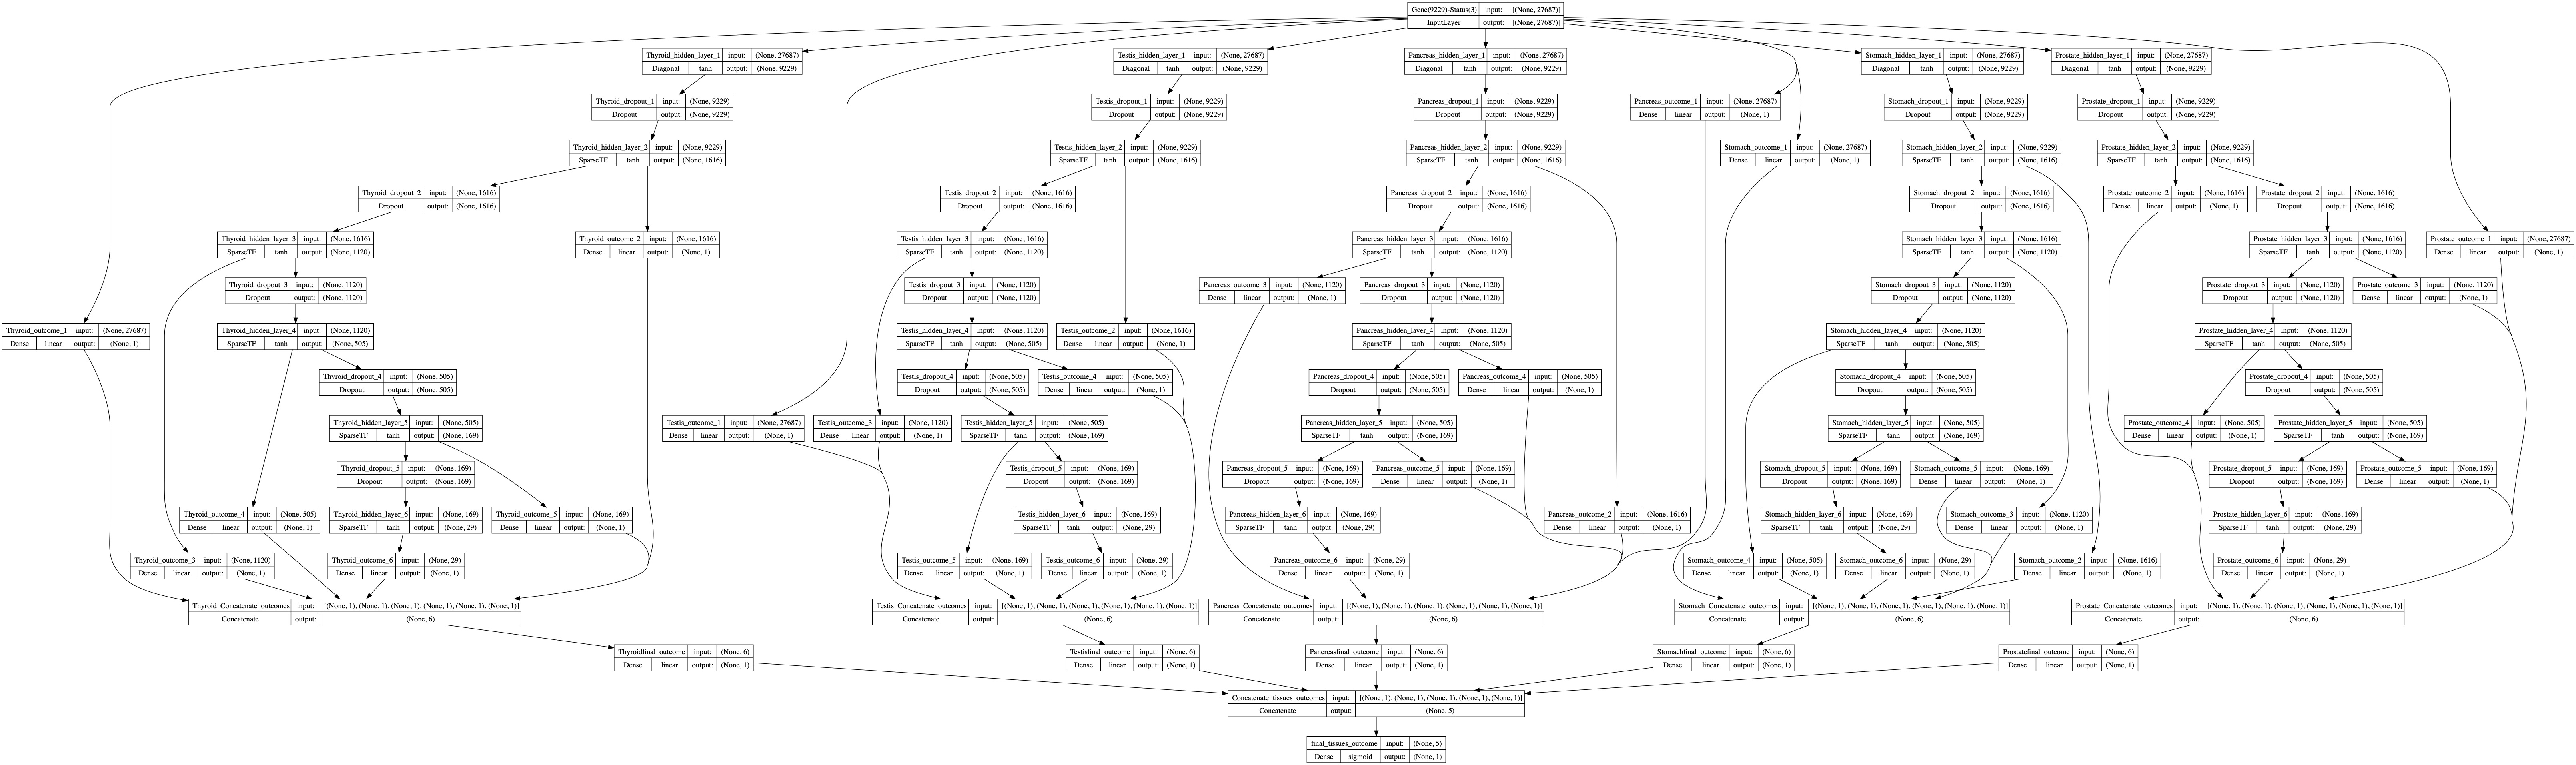

In [13]:
plot_model(model, to_file = 'pnet_ensemble_model_graph.jpg',expand_nested=True,show_layer_activations=True, show_shapes = True, show_layer_names = True)

In [14]:
callbacks = get_callbacks(x_train, y_train)

In [15]:
history = model.fit(x_train,
                    y_train,
                    epochs=300,
                    batch_size=100,
                    verbose=2,
                    callbacks=callbacks)


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/300


2023-09-02 01:03:59.637104: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


8/8 - 5s - loss: 1.8005 - f1: 0.1478 - lr: 0.0010 - 5s/epoch - 673ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/300
8/8 - 2s - loss: 1.3754 - f1: 0.5083 - lr: 0.0010 - 2s/epoch - 216ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/300
8/8 - 2s - loss: 1.1791 - f1: 0.7410 - lr: 0.0010 - 2s/epoch - 210ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/300
8/8 - 2s - loss: 1.0406 - f1: 0.6220 - lr: 0.0010 - 2s/epoch - 209ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.001.
Epoch 5/300
8/8 - 2s - loss: 0.9348 - f1: 0.6779 - lr: 0.0010 - 2s/epoch - 204ms/step

Epoch 6: LearningRateScheduler setting learning rate to 0.001.
Epoch 6/300
8/8 - 2s - loss: 0.8575 - f1: 0.8044 - lr: 0.0010 - 2s/epoch - 216ms/step

Epoch 7: LearningRateScheduler setting learning rate to 0.001.
Epoch 7/300
8/8 - 2s - loss: 0.7904 - f1: 0.8025 - lr: 0.0010 - 2s/epoch - 206ms/step

Epoch 8: LearningRateSche

Epoch 55/300
8/8 - 2s - loss: 0.2479 - f1: 0.9949 - lr: 2.5000e-04 - 2s/epoch - 205ms/step

Epoch 56: LearningRateScheduler setting learning rate to 0.00025.
Epoch 56/300
8/8 - 2s - loss: 0.2471 - f1: 0.9946 - lr: 2.5000e-04 - 2s/epoch - 195ms/step

Epoch 57: LearningRateScheduler setting learning rate to 0.00025.
Epoch 57/300
8/8 - 1s - loss: 0.2464 - f1: 0.9942 - lr: 2.5000e-04 - 1s/epoch - 177ms/step

Epoch 58: LearningRateScheduler setting learning rate to 0.00025.
Epoch 58/300
8/8 - 1s - loss: 0.2451 - f1: 0.9944 - lr: 2.5000e-04 - 1s/epoch - 179ms/step

Epoch 59: LearningRateScheduler setting learning rate to 0.00025.
Epoch 59/300
8/8 - 2s - loss: 0.2445 - f1: 0.9932 - lr: 2.5000e-04 - 2s/epoch - 210ms/step

Epoch 60: LearningRateScheduler setting learning rate to 0.00025.
Epoch 60/300
8/8 - 2s - loss: 0.2436 - f1: 0.9923 - lr: 2.5000e-04 - 2s/epoch - 209ms/step

Epoch 61: LearningRateScheduler setting learning rate to 0.00025.
Epoch 61/300
8/8 - 2s - loss: 0.2424 - f1: 0.9949 - 

Epoch 107/300
8/8 - 2s - loss: 0.2119 - f1: 0.9948 - lr: 6.2500e-05 - 2s/epoch - 195ms/step

Epoch 108: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 108/300
8/8 - 2s - loss: 0.2117 - f1: 0.9942 - lr: 6.2500e-05 - 2s/epoch - 207ms/step

Epoch 109: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 109/300
8/8 - 2s - loss: 0.2114 - f1: 0.9939 - lr: 6.2500e-05 - 2s/epoch - 190ms/step

Epoch 110: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 110/300
8/8 - 2s - loss: 0.2112 - f1: 0.9952 - lr: 6.2500e-05 - 2s/epoch - 194ms/step

Epoch 111: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 111/300
8/8 - 2s - loss: 0.2110 - f1: 0.9936 - lr: 6.2500e-05 - 2s/epoch - 196ms/step

Epoch 112: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 112/300
8/8 - 2s - loss: 0.2108 - f1: 0.9940 - lr: 6.2500e-05 - 2s/epoch - 189ms/step

Epoch 113: LearningRateScheduler setting learning rate to 6.25e-05.
Epoch 113/300
8/8 - 2s - loss: 0.2

Epoch 158/300
8/8 - 1s - loss: 0.2035 - f1: 0.9713 - lr: 1.5625e-05 - 1s/epoch - 174ms/step

Epoch 159: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 159/300
8/8 - 1s - loss: 0.2035 - f1: 0.9946 - lr: 1.5625e-05 - 1s/epoch - 187ms/step

Epoch 160: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 160/300
8/8 - 2s - loss: 0.2035 - f1: 0.9935 - lr: 1.5625e-05 - 2s/epoch - 196ms/step

Epoch 161: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 161/300
8/8 - 1s - loss: 0.2034 - f1: 0.9945 - lr: 1.5625e-05 - 1s/epoch - 171ms/step

Epoch 162: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 162/300
8/8 - 2s - loss: 0.2034 - f1: 0.9943 - lr: 1.5625e-05 - 2s/epoch - 208ms/step

Epoch 163: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 163/300
8/8 - 2s - loss: 0.2033 - f1: 0.8693 - lr: 1.5625e-05 - 2s/epoch - 192ms/step

Epoch 164: LearningRateScheduler setting learning rate to 1.5625e-05.
Epoch 164/300
8/8 - 1s


Epoch 209: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 209/300
8/8 - 2s - loss: 0.2014 - f1: 0.9945 - lr: 3.9063e-06 - 2s/epoch - 189ms/step

Epoch 210: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 210/300
8/8 - 2s - loss: 0.2014 - f1: 0.9947 - lr: 3.9063e-06 - 2s/epoch - 210ms/step

Epoch 211: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 211/300
8/8 - 2s - loss: 0.2014 - f1: 0.9945 - lr: 3.9063e-06 - 2s/epoch - 213ms/step

Epoch 212: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 212/300
8/8 - 2s - loss: 0.2014 - f1: 0.9944 - lr: 3.9063e-06 - 2s/epoch - 209ms/step

Epoch 213: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 213/300
8/8 - 2s - loss: 0.2014 - f1: 0.9948 - lr: 3.9063e-06 - 2s/epoch - 197ms/step

Epoch 214: LearningRateScheduler setting learning rate to 3.90625e-06.
Epoch 214/300
8/8 - 2s - loss: 0.2013 - f1: 0.9946 - lr: 3.9063e-06 - 2s/epoch - 198ms/step

Epoch 215: Lear


Epoch 259: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 259/300
8/8 - 1s - loss: 0.2009 - f1: 0.9947 - lr: 9.7656e-07 - 1s/epoch - 185ms/step

Epoch 260: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 260/300
8/8 - 2s - loss: 0.2009 - f1: 0.9949 - lr: 9.7656e-07 - 2s/epoch - 205ms/step

Epoch 261: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 261/300
8/8 - 1s - loss: 0.2009 - f1: 0.9939 - lr: 9.7656e-07 - 1s/epoch - 174ms/step

Epoch 262: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 262/300
8/8 - 2s - loss: 0.2009 - f1: 0.9940 - lr: 9.7656e-07 - 2s/epoch - 222ms/step

Epoch 263: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 263/300
8/8 - 1s - loss: 0.2008 - f1: 0.9942 - lr: 9.7656e-07 - 1s/epoch - 174ms/step

Epoch 264: LearningRateScheduler setting learning rate to 9.765625e-07.
Epoch 264/300
8/8 - 1s - loss: 0.2008 - f1: 0.9937 - lr: 9.7656e-07 - 1s/epoch - 175ms/step

Epoch 265

In [17]:
y_pred = model.predict(x_test)
get_th(y_test, y_pred)

10/10 [==============================] - 0s 27ms/step
Best threshold to maximize the F1-score: 0.19999999999999996

Metrics for best threshold:
    accuracy  precision        f1  recall   th
10  0.819079   0.718447  0.729064    0.74  0.2


,accuracy,precision,f1,recall,th
0,0.753289,0.589928,0.686192,0.82,0.10
1,0.766447,0.609023,0.695279,0.81,0.11
2,0.779605,0.629921,0.704846,0.80,0.12
3,0.792763,0.650407,0.717489,0.80,0.13
4,0.802632,0.666667,0.727273,0.80,0.14
...,...,...,...,...,...
75,0.750000,0.815789,0.449275,0.31,0.85
76,0.746711,0.810811,0.437956,0.30,0.86
77,0.740132,0.800000,0.414815,0.28,0.87
78,0.736842,0.794118,0.402985,0.27,0.88
